# DA Mini Project
* 주제 : 온라인 학습 플랫폼 사용자 행동 패턴 분석
* 개요 :
```
이번 프로젝트는 학습 서비스를 이용하는 독자들 중 누가 서비스 구독을 연장할지 예측하기 위한 사전 파악에 초점을 맞추고 있습니다. 우리의 목표는 유저들의 학습 습관, 선호도, 이용 행태 등 다양한 측면을 면밀히 분석하는 것입니다.


이를 위해, 우리는 유저들의 학습 패턴, 서비스 이용 시간, 콘텐츠에 대한 반응, 그리고 이들이 얼마나 자주 서비스를 이용하는지 등 다양한 데이터를 수집하고 분석할 계획입니다. 이 데이터는 유저들이 서비스에 얼마나 만족하고 있는지, 어떤 요소들이 그들의 구독 결정에 영향을 미치는지 이해하는 데 중요한 역할을 할 것입니다.
```
* 데이터셋 : mini.csv
    * 메타데이터
        * user_id: 사용자의 고유 식별자
        * subscription_duration: 사용자가 서비스에 가입한 기간 (월)
        * recent_login_time: 사용자가 마지막으로 로그인한 시간 (일)
        * average_login_time:  사용자의 일반적인 로그인 시간
        * average_time_per_learning_session: 각 학습 세션에 소요된 평균 시간 (분)
        * monthly_active_learning_days: 월간 활동적인 학습 일수
        * total_completed_courses: 완료한 총 코스 수
        * recent_learning_achievement: 최근 학습 성취도
        * abandoned_learning_sessions: 중단된 학습 세션 수
        * community_engagement_level: 커뮤니티 참여도
        * preferred_difficulty_level: 선호하는 난이도
        * subscription_type: 구독 유형
        * customer_inquiry_history: 고객 문의 이력
        * payment_pattern : 사용자의 지난 3개월 간의 결제 패턴을 10진수로 표현한 값.
          - 7: 3개월 모두 결제함
          - 6: 첫 2개월은 결제했으나 마지막 달에는 결제하지 않음
          - 5: 첫 달과 마지막 달에 결제함
          - 4: 첫 달에만 결제함
          - 3: 마지막 2개월에 결제함
          - 2: 가운데 달에만 결제함
          - 1: 마지막 달에만 결제함
          - 0: 3개월 동안 결제하지 않음
        * target: 사용자가 다음 달에도 구독을 계속할지 (1) 또는 취소할지 (0)를 나타냄

In [1]:
import pandas as pd

In [23]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
mini_data = pd.read_table('data/mini.csv',sep=',')

In [3]:
mini_data.head()

,user_id,subscription_duration,recent_login_time,average_login_time,average_time_per_learning_session,monthly_active_learning_days,total_completed_courses,recent_learning_achievement,abandoned_learning_sessions,community_engagement_level,preferred_difficulty_level,subscription_type,customer_inquiry_history,payment_pattern,target
0,b919c29d,13,14,14.946163,8.427187,18,16,68.360455,3,4,Low,Basic,4,5,0
1,a0a60abb,16,18,18.453224,72.646087,16,13,97.567322,2,3,Medium,Basic,1,6,1
2,b9f171ae,22,1,16.195228,21.774492,13,14,94.358763,3,4,Medium,Premium,0,7,1
3,5dc0ba8b,1,19,17.628656,42.659066,19,18,70.153228,0,3,Low,Basic,1,0,1
4,65c83654,4,5,21.390656,30.744287,19,10,81.917908,2,4,Medium,Basic,3,0,1


In [4]:
mini_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   user_id                            10000 non-null  object 
 1   subscription_duration              10000 non-null  int64  
 2   recent_login_time                  10000 non-null  int64  
 3   average_login_time                 10000 non-null  float64
 4   average_time_per_learning_session  10000 non-null  float64
 5   monthly_active_learning_days       10000 non-null  int64  
 6   total_completed_courses            10000 non-null  int64  
 7   recent_learning_achievement        10000 non-null  float64
 8   abandoned_learning_sessions        10000 non-null  int64  
 9   community_engagement_level         10000 non-null  int64  
 10  preferred_difficulty_level         10000 non-null  object 
 11  subscription_type                  10000 non-null  obje

In [5]:
mini_data.describe(include='all')

,user_id,subscription_duration,recent_login_time,average_login_time,average_time_per_learning_session,monthly_active_learning_days,total_completed_courses,recent_learning_achievement,abandoned_learning_sessions,community_engagement_level,preferred_difficulty_level,subscription_type,customer_inquiry_history,payment_pattern,target
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000
unique,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2,NaN,NaN,NaN
top,b919c29d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,Basic,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4992,5979,NaN,NaN,NaN
mean,NaN,11.897400,15.013200,14.994076,54.917720,12.545400,12.227500,75.029513,3.043600,3.886100,NaN,NaN,2.010500,3.502900,0.619900
std,NaN,6.600896,8.362573,3.001869,56.024310,6.932239,3.634125,9.968529,1.755052,1.262175,NaN,NaN,1.420983,2.311261,0.485435
min,NaN,1.000000,1.000000,2.366189,0.011515,1.000000,1.000000,35.941755,0.000000,1.000000,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,6.000000,8.000000,13.025597,15.276611,7.000000,10.000000,68.278054,2.000000,3.000000,NaN,NaN,1.000000,1.000000,0.000000
50%,NaN,12.000000,15.000000,14.979228,37.578818,13.000000,12.000000,75.126061,3.000000,4.000000,NaN,NaN,2.000000,4.000000,1.000000
75%,NaN,18.000000,22.000000,16.995340,75.584200,19.000000,15.000000,81.718976,4.000000,5.000000,NaN,NaN,3.000000,6.000000,1.000000


In [6]:
len(mini_data)

10000

In [7]:
mini_data.describe()

,subscription_duration,recent_login_time,average_login_time,average_time_per_learning_session,monthly_active_learning_days,total_completed_courses,recent_learning_achievement,abandoned_learning_sessions,community_engagement_level,customer_inquiry_history,payment_pattern,target
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.897400,15.013200,14.994076,54.917720,12.545400,12.227500,75.029513,3.043600,3.886100,2.010500,3.502900,0.619900
std,6.600896,8.362573,3.001869,56.024310,6.932239,3.634125,9.968529,1.755052,1.262175,1.420983,2.311261,0.485435
min,1.000000,1.000000,2.366189,0.011515,1.000000,1.000000,35.941755,0.000000,1.000000,0.000000,0.000000,0.000000
25%,6.000000,8.000000,13.025597,15.276611,7.000000,10.000000,68.278054,2.000000,3.000000,1.000000,1.000000,0.000000
50%,12.000000,15.000000,14.979228,37.578818,13.000000,12.000000,75.126061,3.000000,4.000000,2.000000,4.000000,1.000000
75%,18.000000,22.000000,16.995340,75.584200,19.000000,15.000000,81.718976,4.000000,5.000000,3.000000,6.000000,1.000000
max,23.000000,29.000000,26.998490,503.372616,24.000000,27.000000,112.643828,12.000000,5.000000,10.000000,7.000000,1.000000


In [8]:
mini_data.isnull().sum()

user_id                              0
subscription_duration                0
recent_login_time                    0
average_login_time                   0
average_time_per_learning_session    0
monthly_active_learning_days         0
total_completed_courses              0
recent_learning_achievement          0
abandoned_learning_sessions          0
community_engagement_level           0
preferred_difficulty_level           0
subscription_type                    0
customer_inquiry_history             0
payment_pattern                      0
target                               0
dtype: int64

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 투입 시간

In [11]:
type(mini_data['subscription_duration'][0])

numpy.int64

In [20]:
import matplotlib as mpl
import matplotlib.pylab as plt
import koreanize_matplotlib
import numpy as np

# 2. 참여도

In [32]:
import matplotlib.pyplot as plt

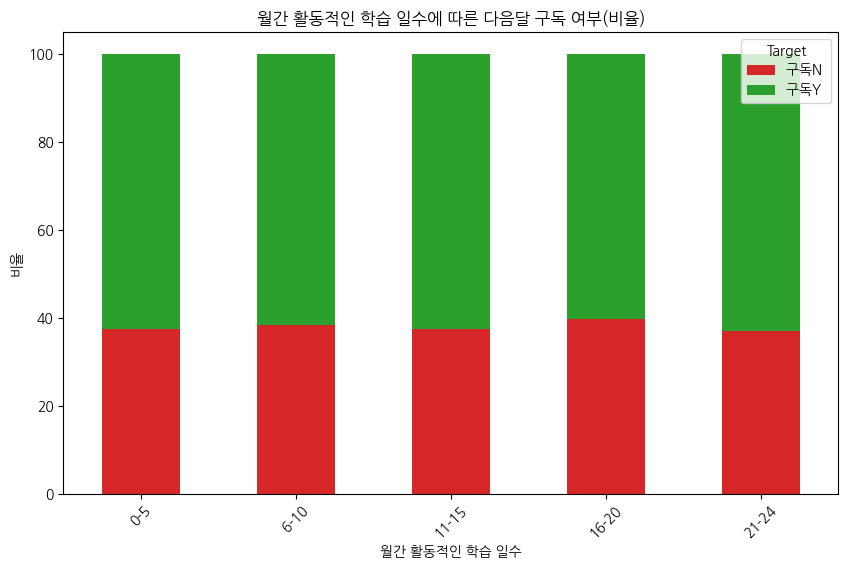

In [51]:
# 구간 나누기
bins = [0, 5, 10, 15, 20, 24]
labels = ['0-5', '6-10', '11-15', '16-20', '21-24']
mini_data['active_days_bin'] = pd.cut(mini_data['monthly_active_learning_days'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['active_days_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = bin_percentages.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#d62728', '#2ca02c'])
plt.title('월간 활동적인 학습 일수에 따른 다음달 구독 여부(비율)')
plt.xlabel('월간 활동적인 학습 일수')
plt.ylabel('비율')
plt.legend(title='Target', labels=['구독N ', '구독Y '])
plt.xticks(rotation=45)

plt.show()

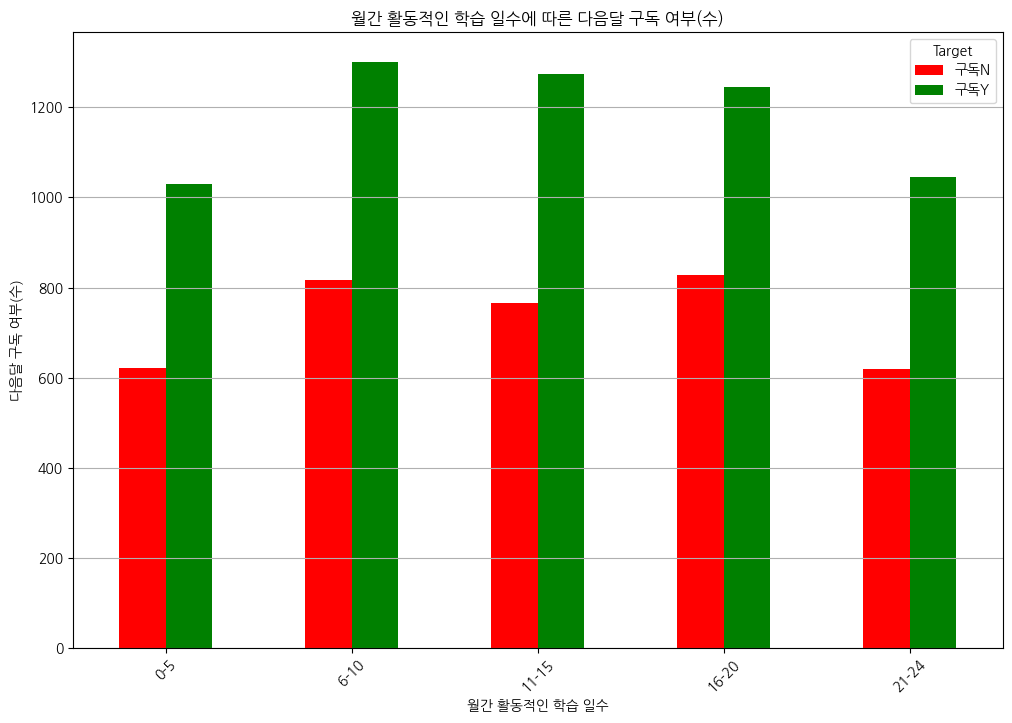

In [52]:
# 구간 나누기
bins = [0, 5, 10, 15, 20, 24]
labels = ['0-5', '6-10', '11-15', '16-20', '21-24']
mini_data['active_days_bin'] = pd.cut(mini_data['monthly_active_learning_days'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['active_days_bin', 'target']).size().unstack(fill_value=0)

# 바 그래프 생성
fig, ax = plt.subplots(figsize=(12, 8))
bin_counts.plot(kind='bar', ax=ax, color=['red', 'green'])

# 그래프 세부 설정
ax.set_title('월간 활동적인 학습 일수에 따른 다음달 구독 여부(수)')
ax.set_xlabel('월간 활동적인 학습 일수')
ax.set_ylabel('다음달 구독 여부(수)')
ax.legend(title='Target', labels=['구독N', '구독Y'])
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

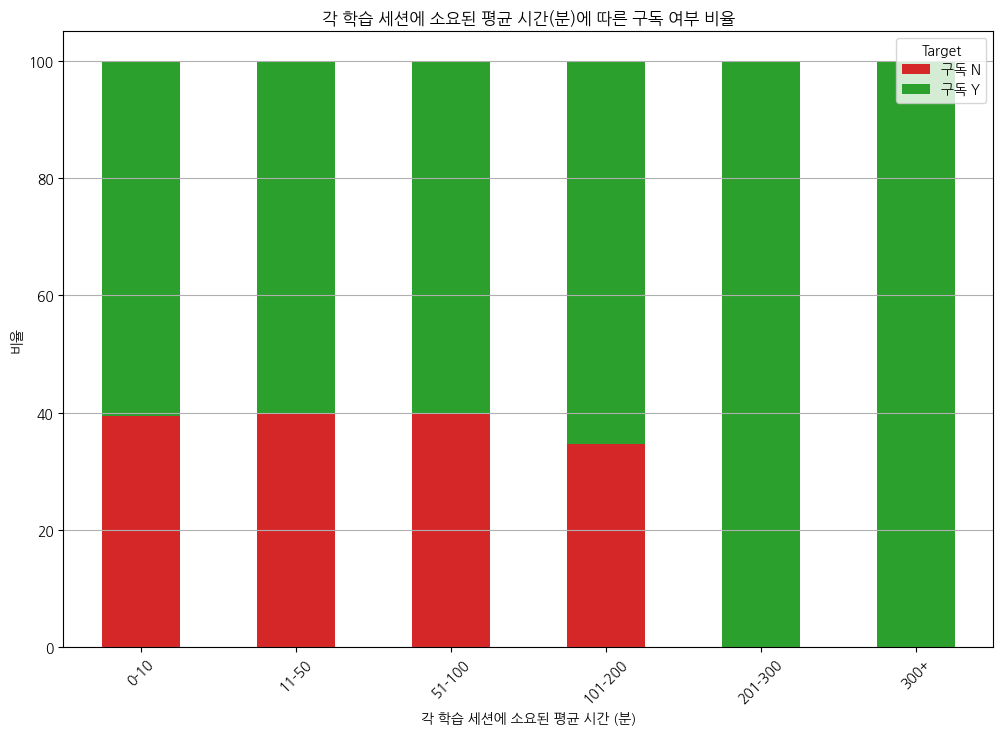

In [61]:
# 구간 설정
bins = [0, 10, 50, 100, 200, 300, 504]
labels = ['0-10', '11-50', '51-100', '101-200', '201-300', '300+']

# 데이터 구간 나누기
mini_data['time_bin'] = pd.cut(mini_data['average_time_per_learning_session'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['time_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = bin_percentages.plot(kind='bar', stacked=True, figsize=(12, 8), color=['#d62728', '#2ca02c'])
plt.title('각 학습 세션에 소요된 평균 시간(분)에 따른 구독 여부 비율')
plt.xlabel('각 학습 세션에 소요된 평균 시간 (분)')
plt.ylabel('비율')
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 범례 이름 설정
plt.legend(title='Target', labels=['구독 N', '구독 Y'])

plt.show()

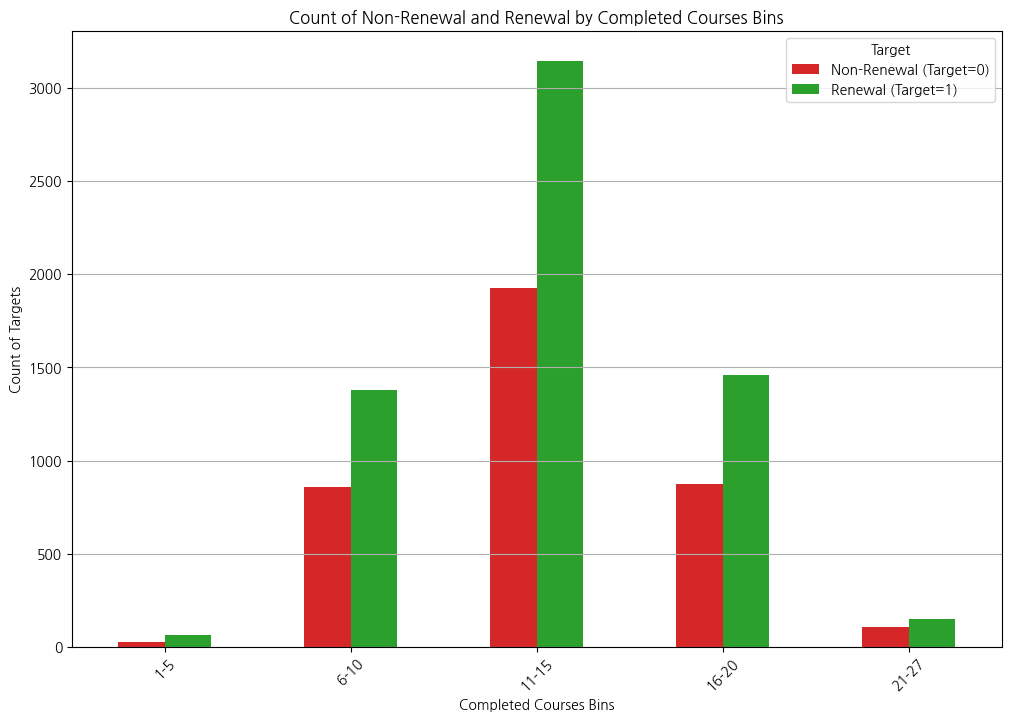

In [64]:
# 구간 설정
bins = [0, 5, 10, 15, 20, 27]  # 최대값 27을 포함
labels = ['1-5', '6-10', '11-15', '16-20', '21-27']

# 데이터 구간 나누기
mini_data['completed_courses_bin'] = pd.cut(mini_data['total_completed_courses'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['completed_courses_bin', 'target']).size().unstack(fill_value=0)

# 바 차트 생성
fig, ax = plt.subplots(figsize=(12, 8))
bin_counts.plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'])

# 그래프 세부 설정
ax.set_title('Count of Non-Renewal and Renewal by Completed Courses Bins')
ax.set_xlabel('Completed Courses Bins')
ax.set_ylabel('Count of Targets')
ax.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

plt.show()

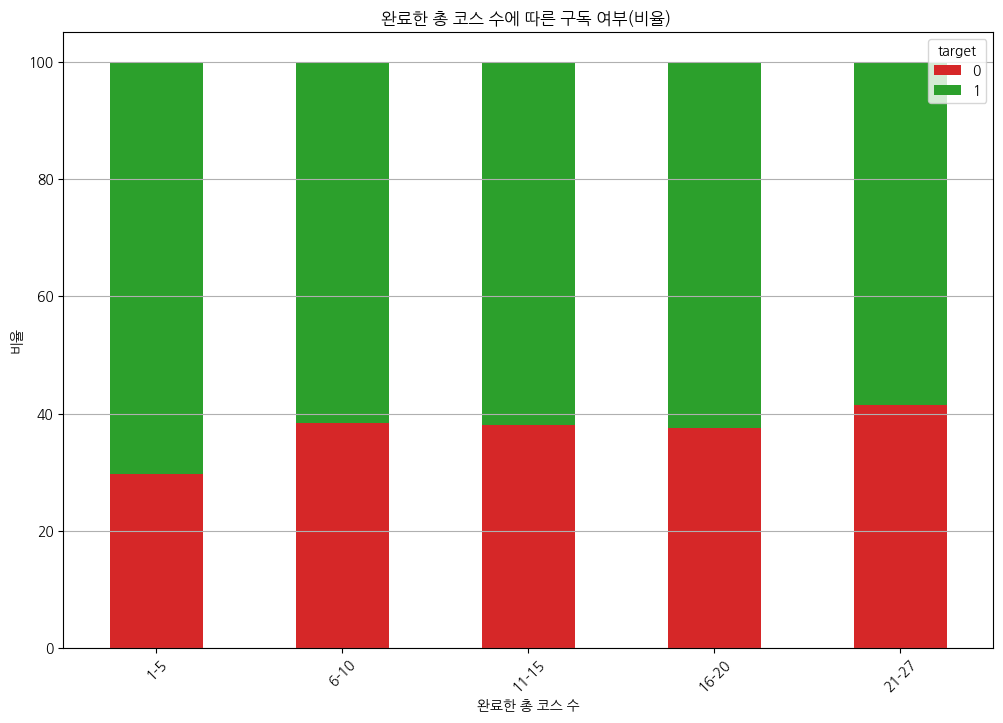

In [68]:
# 구간 설정
bins = [0, 5, 10, 15, 20, 27]  # 최대값 27을 포함
labels = ['1-5', '6-10', '11-15', '16-20', '21-27']

# 데이터 구간 나누기
mini_data['completed_courses_bin'] = pd.cut(mini_data['total_completed_courses'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['completed_courses_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = bin_percentages.plot(kind='bar', stacked=True, figsize=(12, 8), color=['#d62728', '#2ca02c'])
plt.title('완료한 총 코스 수에 따른 구독 여부(비율) ')
plt.xlabel('완료한 총 코스 수')
plt.ylabel('비율')
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

plt.show()

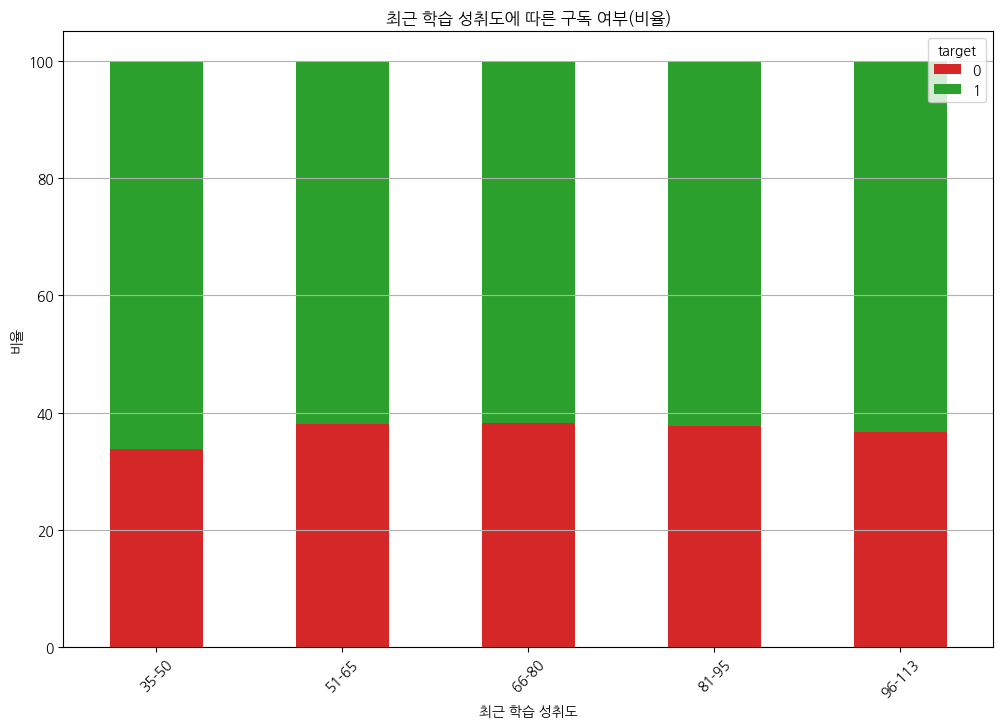

In [72]:
# 구간 설정
bins = [35, 50, 65, 80, 95, 113]  # 최소값과 최대값을 포함하고 세밀하게 구간 분할
labels = ['35-50', '51-65', '66-80', '81-95', '96-113']

# 데이터 구간 나누기
mini_data['achievement_bin'] = pd.cut(mini_data['recent_learning_achievement'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['achievement_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = bin_percentages.plot(kind='bar', stacked=True, figsize=(12, 8), color=['#d62728', '#2ca02c'])
plt.title('최근 학습 성취도에 따른 구독 여부(비율)')
plt.xlabel('최근 학습 성취도')
plt.ylabel('비율')
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

plt.show()

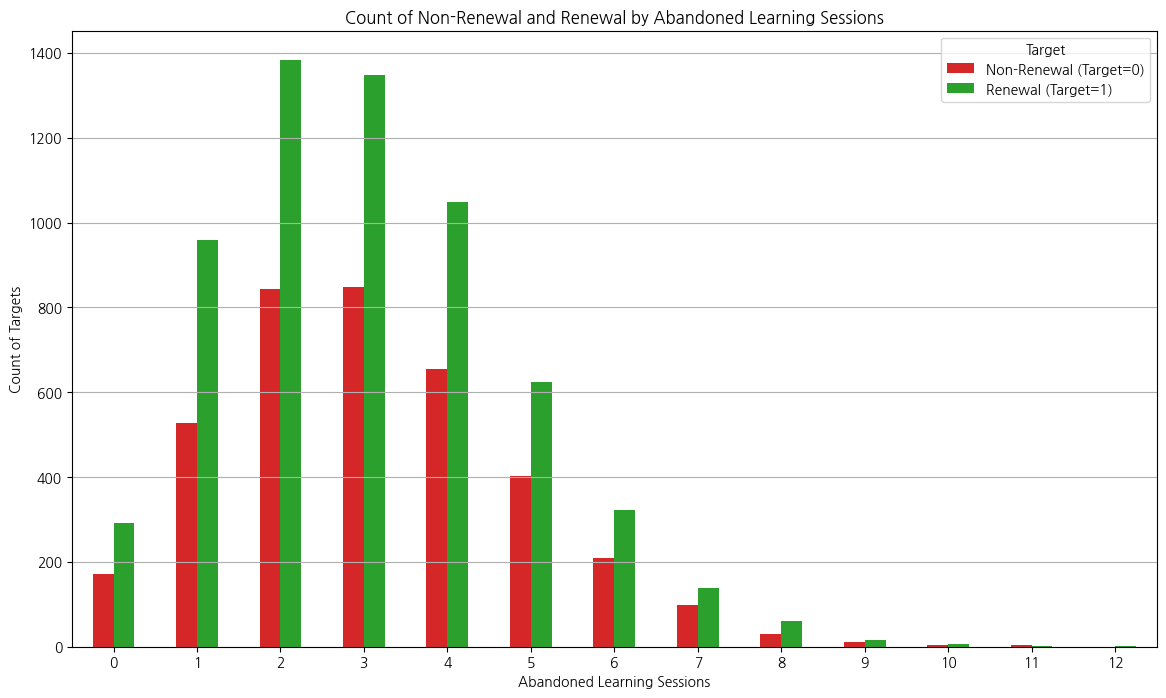

In [73]:
# 구간 설정
bins = list(range(0, 14))  # 0부터 12까지 각각 독립적인 구간으로 설정
labels = [str(x) for x in range(13)]  # 0부터 12까지의 라벨

# 데이터 구간 나누기
mini_data['abandoned_bin'] = pd.cut(mini_data['abandoned_learning_sessions'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['abandoned_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 바 차트 생성
fig, ax = plt.subplots(figsize=(14, 8))
bin_counts.plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'])

# 그래프 세부 설정
ax.set_title('Count of Non-Renewal and Renewal by Abandoned Learning Sessions')
ax.set_xlabel('Abandoned Learning Sessions')
ax.set_ylabel('Count of Targets')
ax.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.xticks(rotation=0)  # X축 라벨 회전 없음
plt.grid(True, axis='y')  # Y축에만 그리드 추가

plt.show()

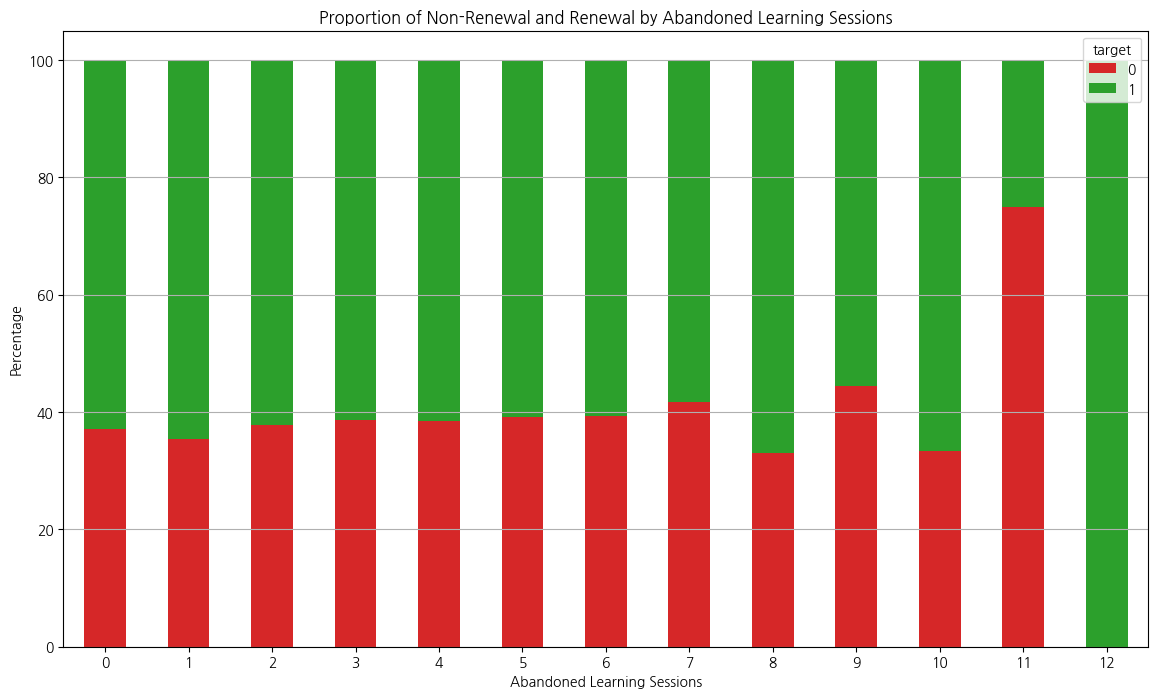

In [75]:
# 구간 설정
bins = list(range(0, 14))  # 0부터 12까지 각각 독립적인 구간으로 설정
labels = [str(x) for x in range(13)]  # 0부터 12까지의 라벨

# 데이터 구간 나누기
mini_data['abandoned_bin'] = pd.cut(mini_data['abandoned_learning_sessions'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['abandoned_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = bin_percentages.plot(kind='bar', stacked=True, figsize=(14, 8), color=['#d62728', '#2ca02c'])
plt.title('Proportion of Non-Renewal and Renewal by Abandoned Learning Sessions')
plt.xlabel('Abandoned Learning Sessions')
plt.ylabel('Percentage')
plt.xticks(rotation=0)  # X축 라벨 회전 없음
plt.grid(True, axis='y')  # Y축에만 그리드 추가


plt.show()

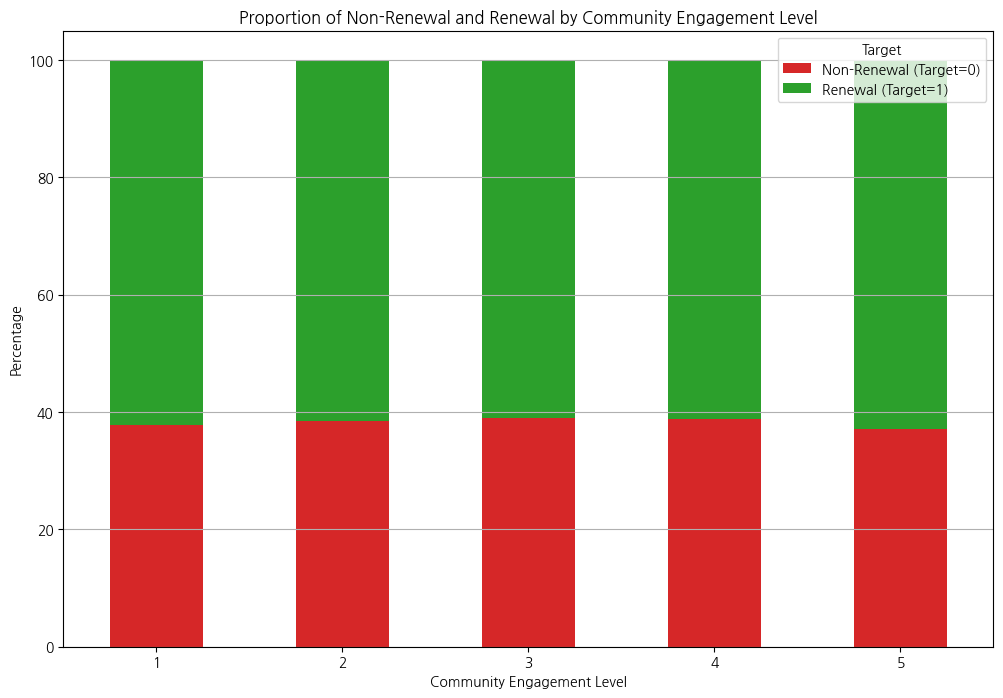

In [77]:
# community_engagement_level별로 target의 0과 1 카운트
engagement_counts = mini_data.groupby(['community_engagement_level', 'target']).size().unstack(fill_value=0)

# 각 community_engagement_level별 target의 0과 1의 합으로 나누어 비율 계산
engagement_percentages = engagement_counts.div(engagement_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = engagement_percentages.plot(kind='bar', stacked=True, figsize=(12, 8), color=['#d62728', '#2ca02c'])
plt.title('Proportion of Non-Renewal and Renewal by Community Engagement Level')
plt.xlabel('Community Engagement Level')
plt.ylabel('Percentage')
plt.xticks(rotation=0)  # X축 라벨 회전 없음
plt.grid(True, axis='y')  # Y축에만 그리드 추가


plt.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.show()

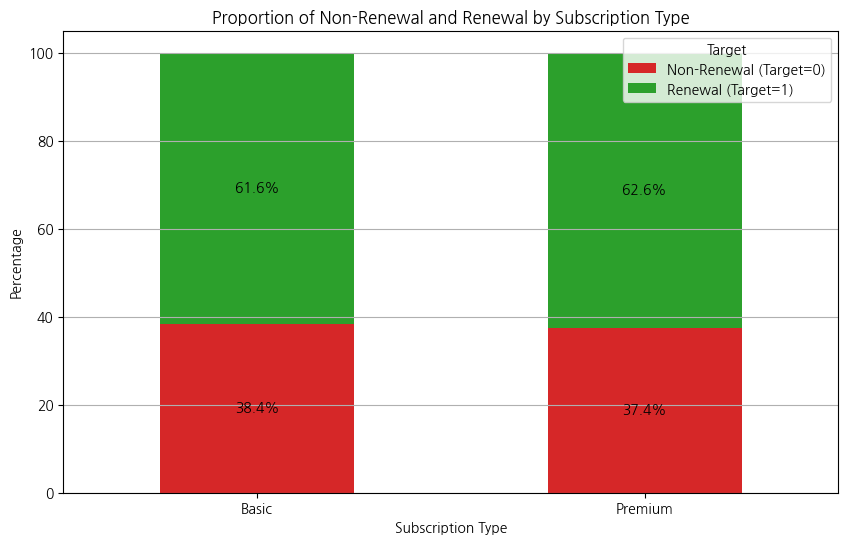

In [78]:
# subscription_type별로 target의 0과 1 카운트
subscription_counts = mini_data.groupby(['subscription_type', 'target']).size().unstack(fill_value=0)

# 각 subscription_type별 target의 0과 1의 합으로 나누어 비율 계산
subscription_percentages = subscription_counts.div(subscription_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = subscription_percentages.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#d62728', '#2ca02c'])
plt.title('Proportion of Non-Renewal and Renewal by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)  # X축 라벨 회전 없음
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 비율 표시 추가
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:  # 비율이 0보다 클 때만 표시
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center')

plt.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.show()

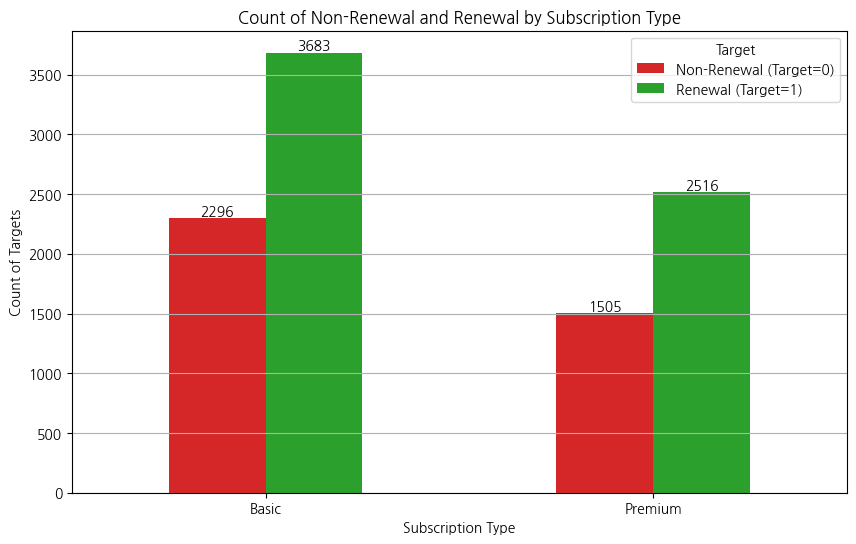

In [79]:
# subscription_type별로 target의 0과 1 카운트
subscription_counts = mini_data.groupby(['subscription_type', 'target']).size().unstack(fill_value=0)

# 바 차트 시각화
fig, ax = plt.subplots(figsize=(10, 6))
subscription_counts.plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'])
plt.title('Count of Non-Renewal and Renewal by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Count of Targets')
plt.xticks(rotation=0)  # X축 라벨 회전 없음
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 수치 표시 추가
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 수치가 0보다 클 때만 표시
        ax.text(p.get_x() + p.get_width() / 2., height, f'{int(height)}', ha='center', va='bottom')

plt.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.show()

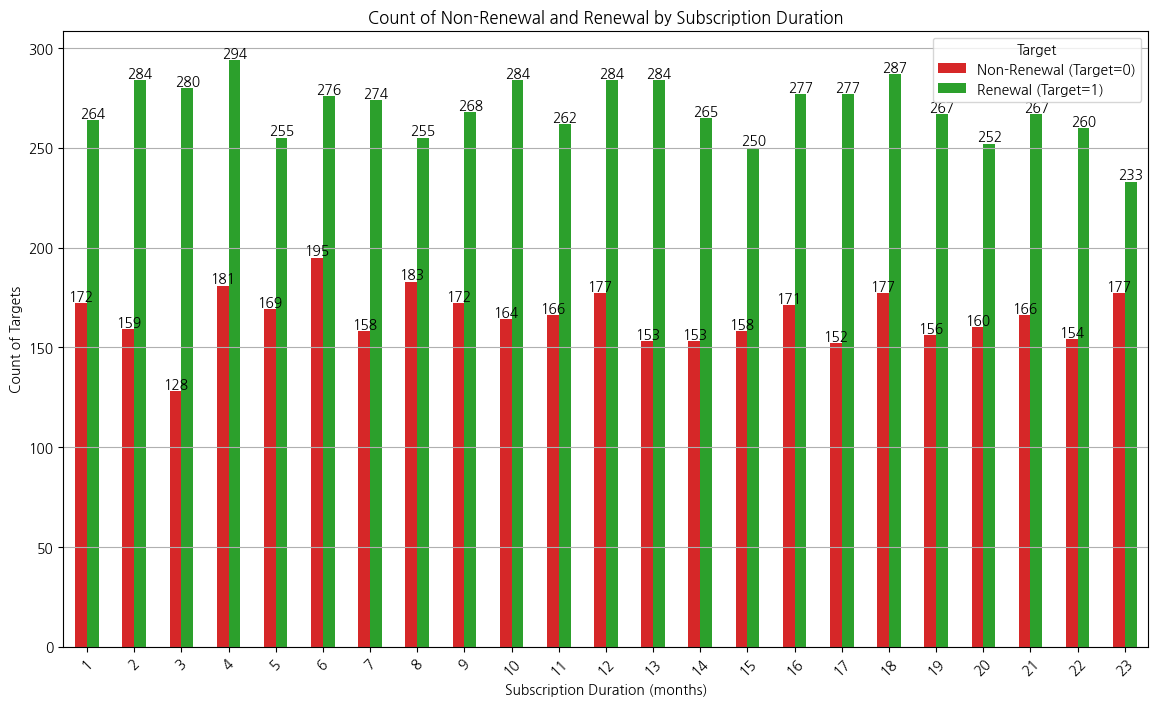

In [80]:
# 구간 설정
bins = list(range(1, 25))  # 1부터 23까지 각각 독립적인 구간으로 설정
labels = [str(x) for x in range(1, 24)]  # 1부터 23까지의 라벨

# 데이터 구간 나누기
mini_data['duration_bin'] = pd.cut(mini_data['subscription_duration'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['duration_bin', 'target']).size().unstack(fill_value=0)

# 바 차트 생성
fig, ax = plt.subplots(figsize=(14, 8))
bin_counts.plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'])

# 그래프 세부 설정
ax.set_title('Count of Non-Renewal and Renewal by Subscription Duration')
ax.set_xlabel('Subscription Duration (months)')
ax.set_ylabel('Count of Targets')
ax.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 수치 표시 추가
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 수치가 0보다 클 때만 표시
        ax.text(p.get_x() + p.get_width() / 2., height, f'{int(height)}', ha='center', va='bottom')

plt.show()

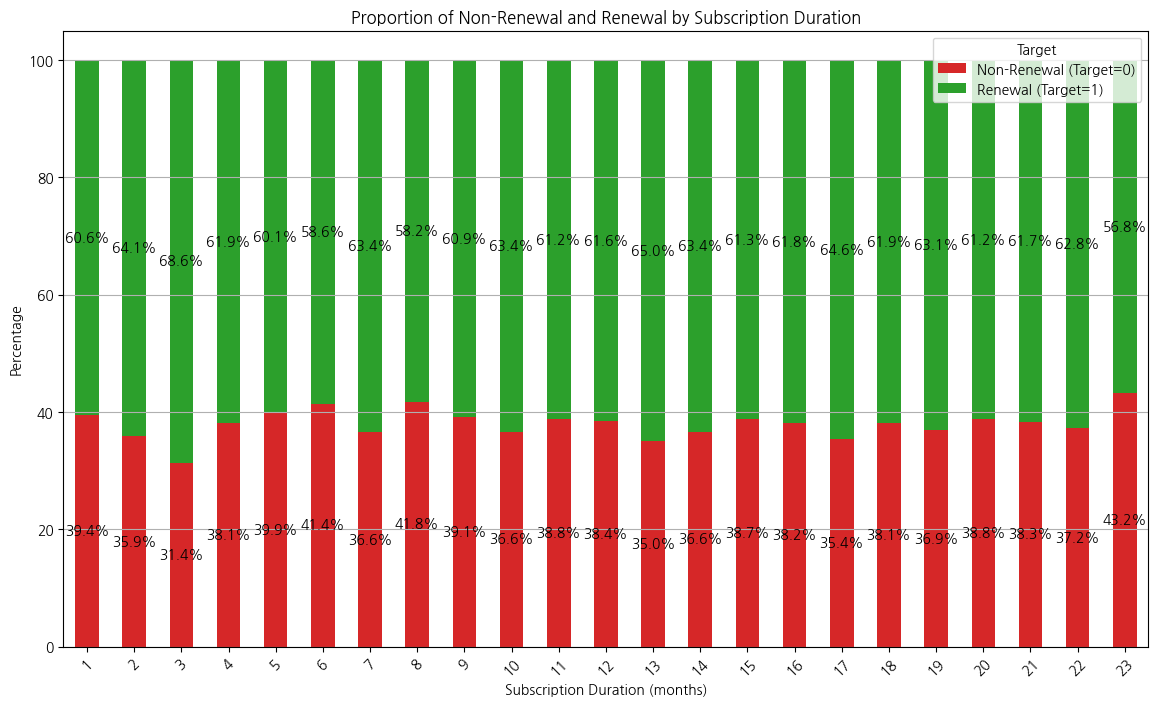

In [81]:
# 구간 설정
bins = list(range(1, 25))  # 1부터 23까지 각각 독립적인 구간으로 설정
labels = [str(x) for x in range(1, 24)]  # 1부터 23까지의 라벨

# 데이터 구간 나누기
mini_data['duration_bin'] = pd.cut(mini_data['subscription_duration'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['duration_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = bin_percentages.plot(kind='bar', stacked=True, figsize=(14, 8), color=['#d62728', '#2ca02c'])
plt.title('Proportion of Non-Renewal and Renewal by Subscription Duration')
plt.xlabel('Subscription Duration (months)')
plt.ylabel('Percentage')
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 비율 표시 추가
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:  # 비율이 0보다 클 때만 표시
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center')

plt.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.show()